# Etapa 1 — Visualização dos resultados
Este notebook **só lê** o que o `etapa1.py` já gerou (CSVs e imagens). Para atualizar os resultados, rode `python etapa1.py` na raiz e depois execute as células de novo (*Run All*).

In [1]:
from pathlib import Path
import textwrap
import pandas as pd
from IPython.display import Image, display, Markdown

# Funciona tanto com o notebook em notebooks/ quanto na raiz do projeto
RAIZ = Path.cwd() if (Path.cwd() / "etapa1.py").exists() else Path.cwd().parent
ASSETS = RAIZ / "relatorio" / "assets"
TABELAS = RAIZ / "relatorio" / "tabelas"
CSV_SENTIMENTO = RAIZ / "dados" / "processados" / "comentarios_sentimento.csv"
CSV_LIMPOS = RAIZ / "dados" / "intermediarios" / "comentarios_limpos.csv"

if not CSV_SENTIMENTO.exists():
    raise FileNotFoundError("Rode `python etapa1.py` na raiz do projeto antes de abrir este notebook.")

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 160)
df = pd.read_csv(CSV_SENTIMENTO)
limpos = pd.read_csv(CSV_LIMPOS)
metodo = df["metodo_sentimento"].iloc[0]
print(f"{len(df)} comentários classificados de {df['video_id'].nunique()} vídeo(s) | método: {metodo}")
if metodo != "pysentimiento":
    print("ATENÇÃO: o pysentimiento não foi usado (léxico de reserva). Não apresente estes resultados como finais.")

372 comentários classificados de 3 vídeo(s) | método: pysentimiento


## 1. Visão geral da base
Quantos comentários entraram, quantos ficaram de fora e por quê (idioma ou texto vazio).

In [2]:
visao = pd.DataFrame({
    "coletados": limpos.groupby("video_id").size(),
    "classificados": df.groupby("video_id").size(),
}).fillna(0).astype(int)
visao["fora do recorte"] = visao["coletados"] - visao["classificados"]
visao["principais"] = df[df.tipo == "principal"].groupby("video_id").size()
visao["respostas"] = df[df.tipo == "resposta"].groupby("video_id").size()
display(visao.fillna(0).astype(int))
print("Idiomas detectados (todos os coletados):", limpos["idioma"].value_counts().to_dict())

,coletados,classificados,fora do recorte,principais,respostas
video_id,,,,,
40QyA5f3Qo0,137,137,0,115,22
Sd_PpMlPmWY,180,179,1,126,53
qD3zyh7-hpw,56,56,0,35,21


Idiomas detectados (todos os coletados): {'pt': 298, 'indefinido': 63, 'en': 3, 'es': 3, 'ca': 2, 'fr': 1, 'it': 1, 'pl': 1, 'hr': 1}


## 2. Sentimento por vídeo
Proporções com intervalo de confiança de 95% (Wilson). **Intervalos que se sobrepõem = não dá para dizer que os vídeos diferem.**

,vídeo,n,positivo,neutro,negativo,score médio
0,7 Editores Incríveis para Programar Online que Você Deveria Experimentar,137,52% [44–60],41% [33–49],7% [4–13],0.42
1,Quais IDEs os engenheiros de software adoram e por quê?,179,28% [22–36],54% [46–61],18% [13–24],0.08
2,"Qual a Melhor IDE para Python? PyCharm, VSCode, Jupyter, Colab",56,29% [18–41],57% [44–69],14% [7–26],0.17


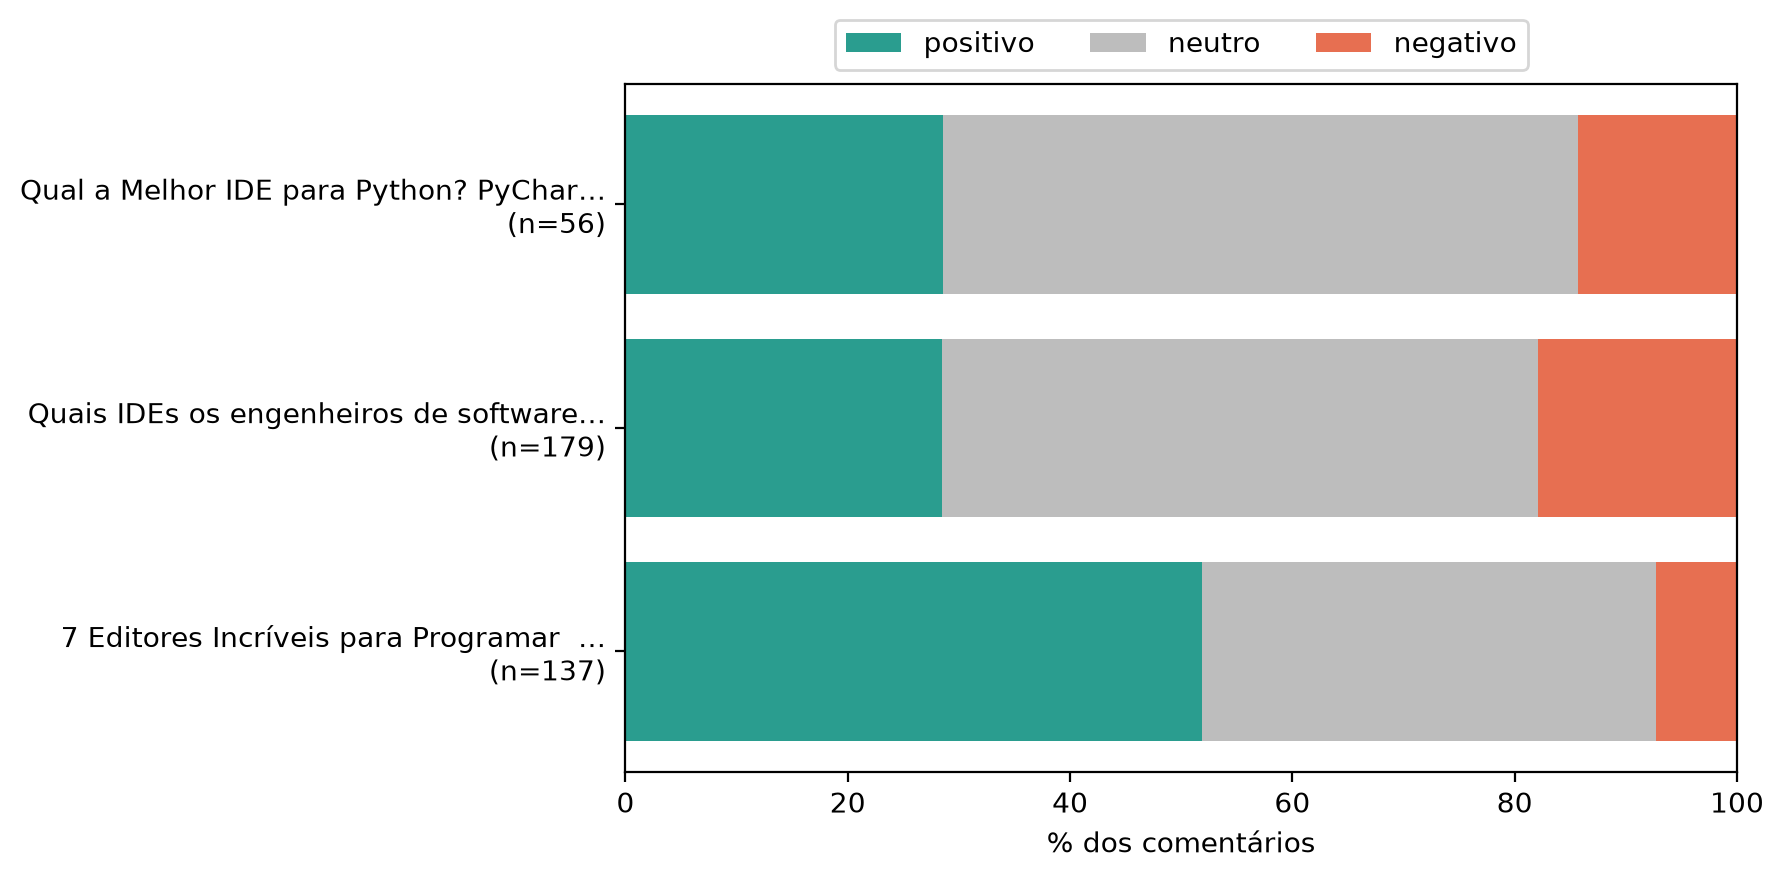

In [3]:
resumo = pd.read_csv(TABELAS / "resumo_por_video.csv")
tabela = pd.DataFrame({"vídeo": resumo["titulo"], "n": resumo["n"]})
for r in ["positivo", "neutro", "negativo"]:
    tabela[r] = [f"{p:.0f}% [{lo:.0f}–{hi:.0f}]" for p, lo, hi in
                 zip(resumo[f"pct_{r}"], resumo[f"ic_{r}_inf"], resumo[f"ic_{r}_sup"])]
tabela["score médio"] = resumo["score_medio"].round(2)
display(tabela)
display(Image(filename=ASSETS / "sentimento_por_video.png"))

## 3. Distribuição do score
Score = P(positivo) − P(negativo), de −1 a +1. Picos nas pontas indicam comentários polarizados; pico no meio, maioria neutra.

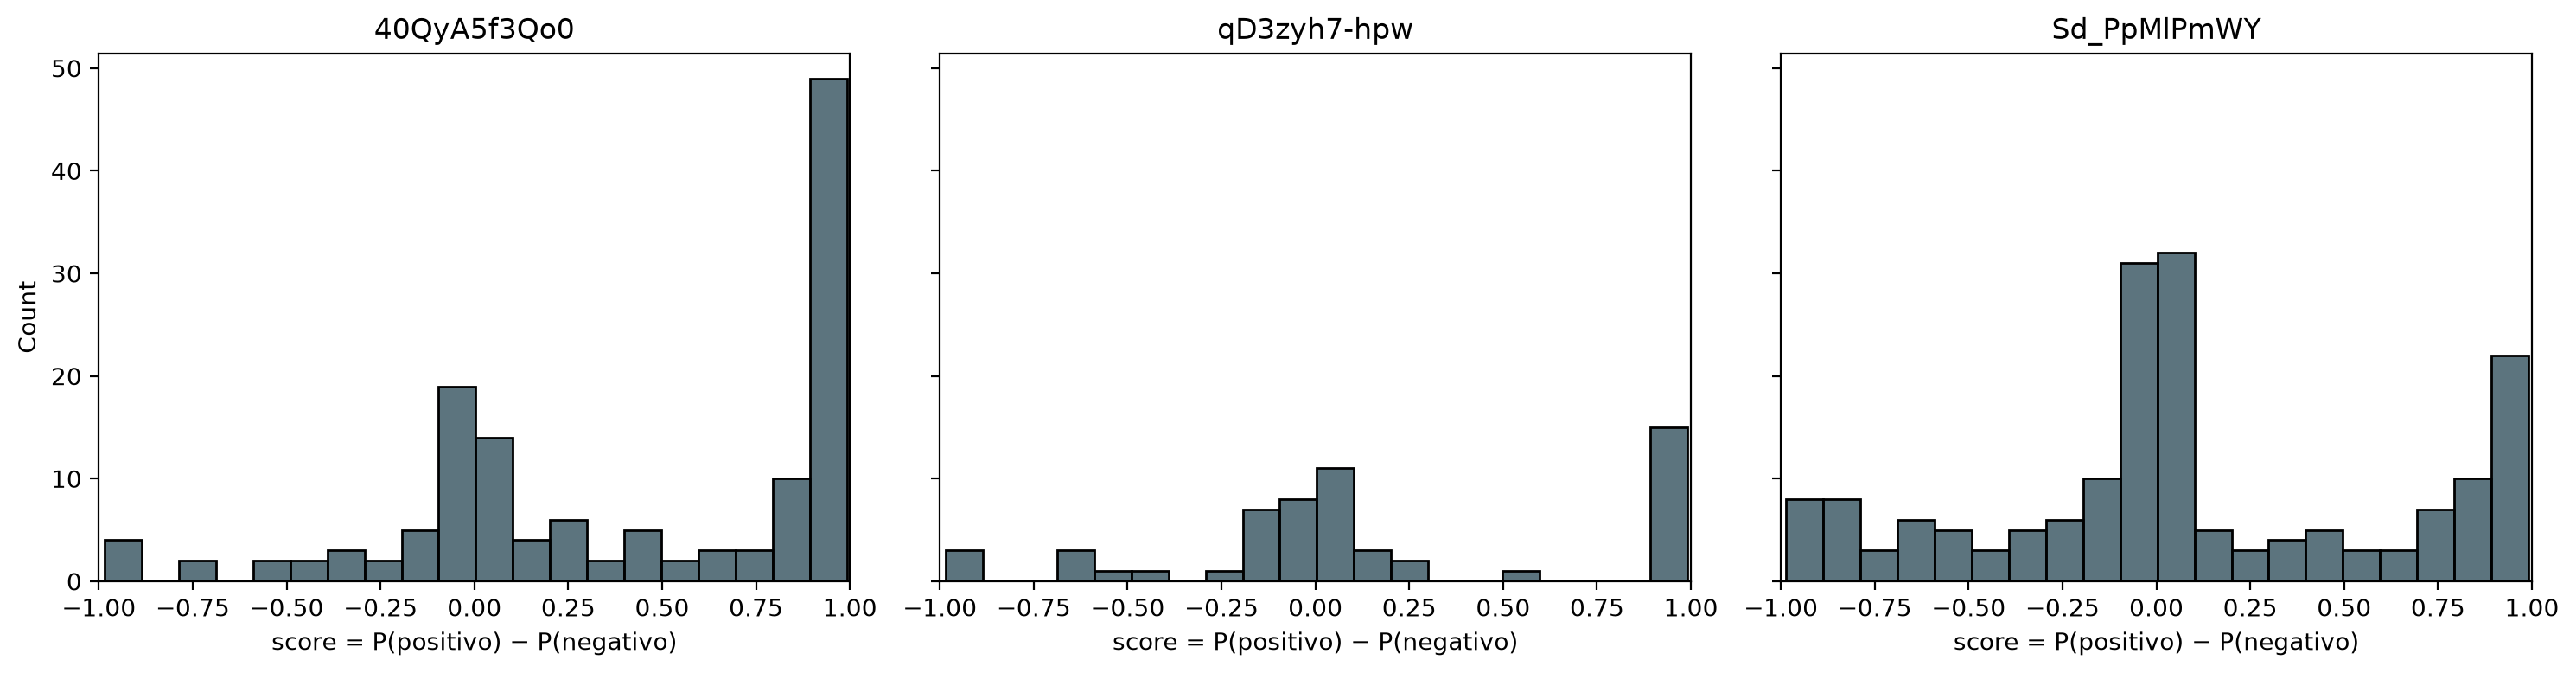

In [4]:
display(Image(filename=ASSETS / "distribuicao_score.png"))

## 4. Principais × respostas
As respostas costumam ter outro tom que os comentários principais.

In [5]:
tipo = pd.read_csv(TABELAS / "resumo_por_tipo.csv")
display(tipo.round(1))

,tipo,positivo,neutro,negativo,n
0,principal,43.1,44.2,12.7,276
1,resposta,19.8,64.6,15.6,96


## 5. Termos mais frequentes por sentimento
Lemas de substantivos, adjetivos, verbos e nomes próprios (spaCy). Mostra o **porquê** do resultado.

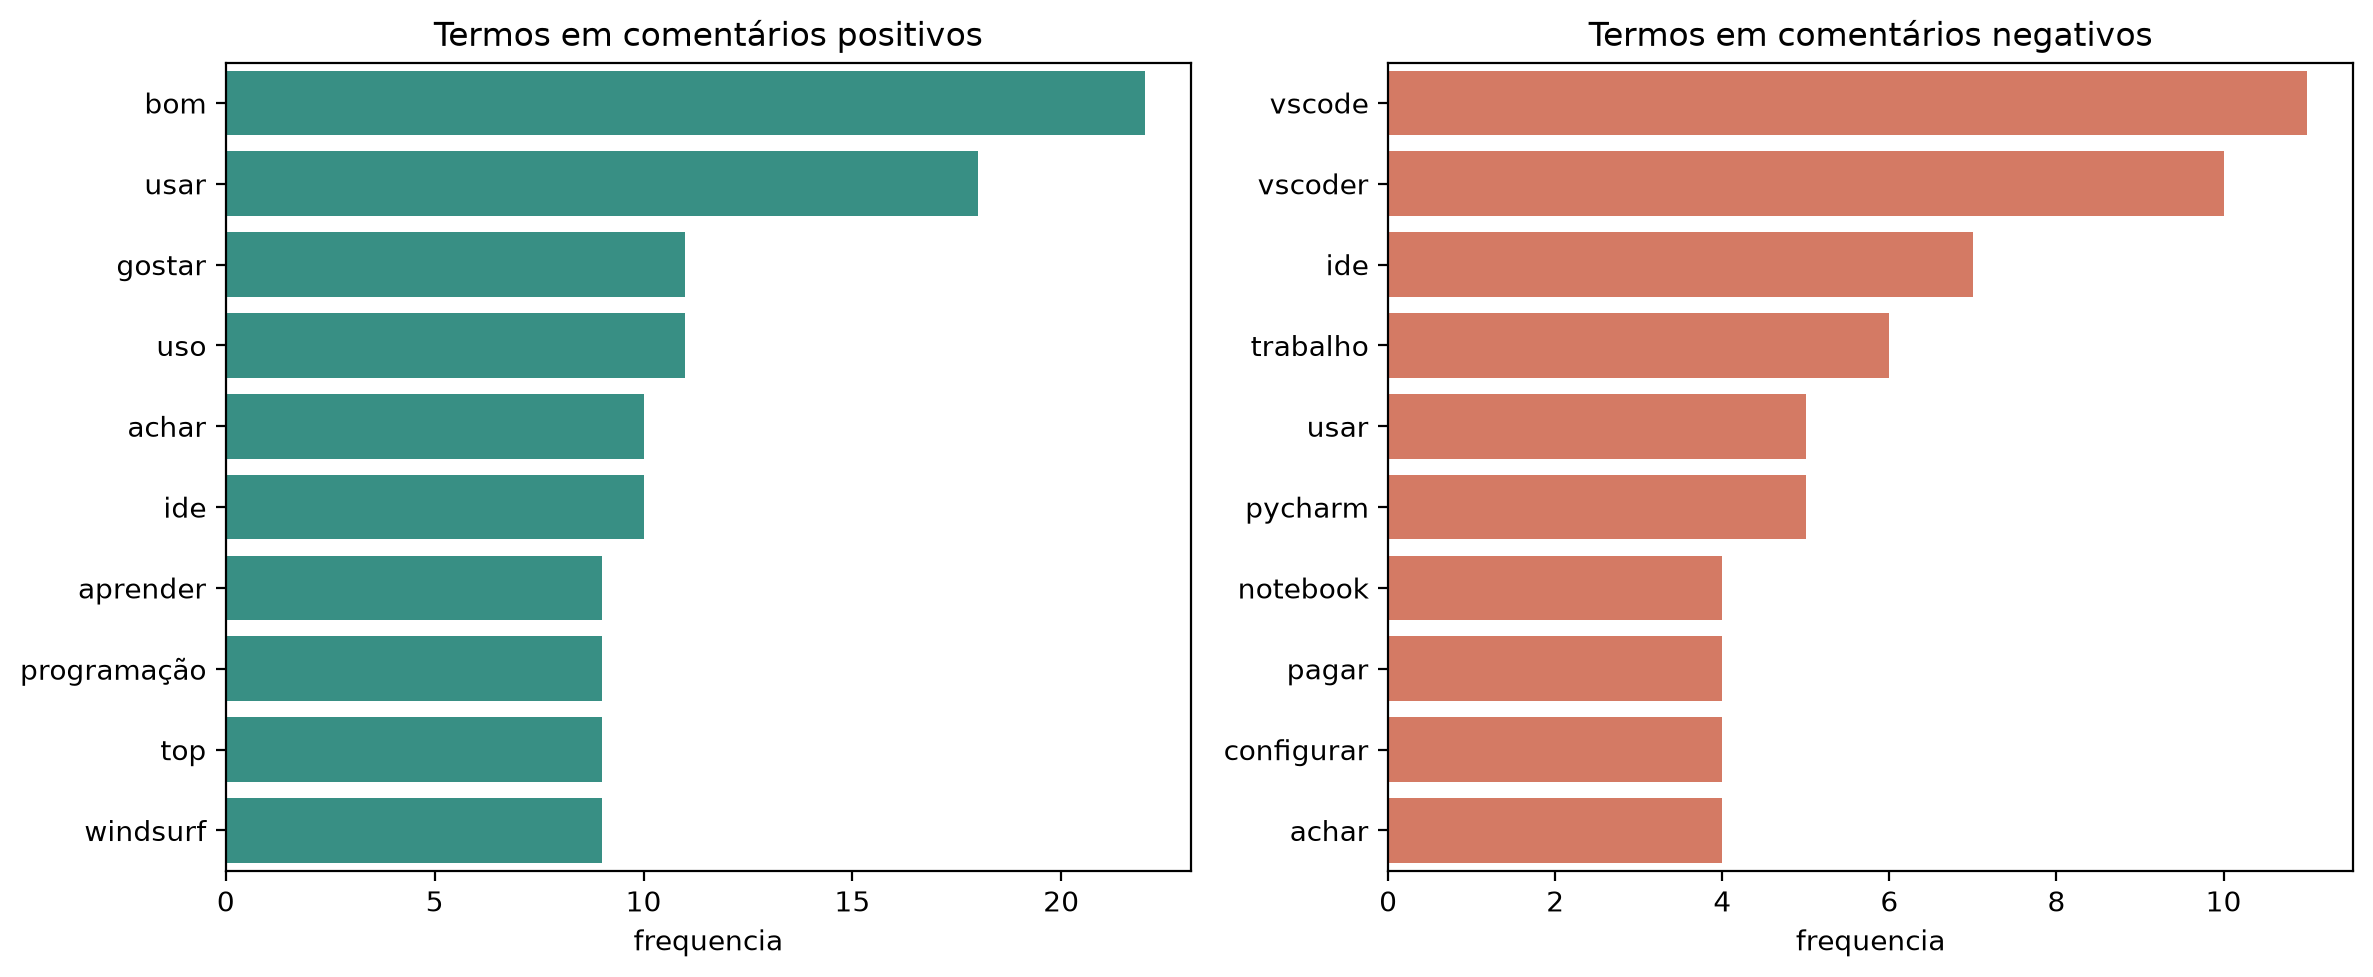

sentimento,negativo,neutro,positivo
posição,,,
1,vscode,usar,bom
2,vscoder,uso,usar
3,ide,vscoder,gostar
4,trabalho,ide,uso
5,usar,achar,achar
6,pycharm,falar,ide
7,notebook,vscode,aprender
8,pagar,vir,programação
9,configurar,cursor,top


In [6]:
display(Image(filename=ASSETS / "termos_por_sentimento.png"))
termos = pd.read_csv(TABELAS / "termos_por_sentimento.csv")
display(termos.pivot_table(index=termos.groupby("sentimento").cumcount() + 1, columns="sentimento",
                           values="termo", aggfunc="first").rename_axis("posição"))

## 6. Nuvem de palavras por vídeo

**7 Editores Incríveis para Programar  Online que Você Deveria Experimentar** (`40QyA5f3Qo0`)

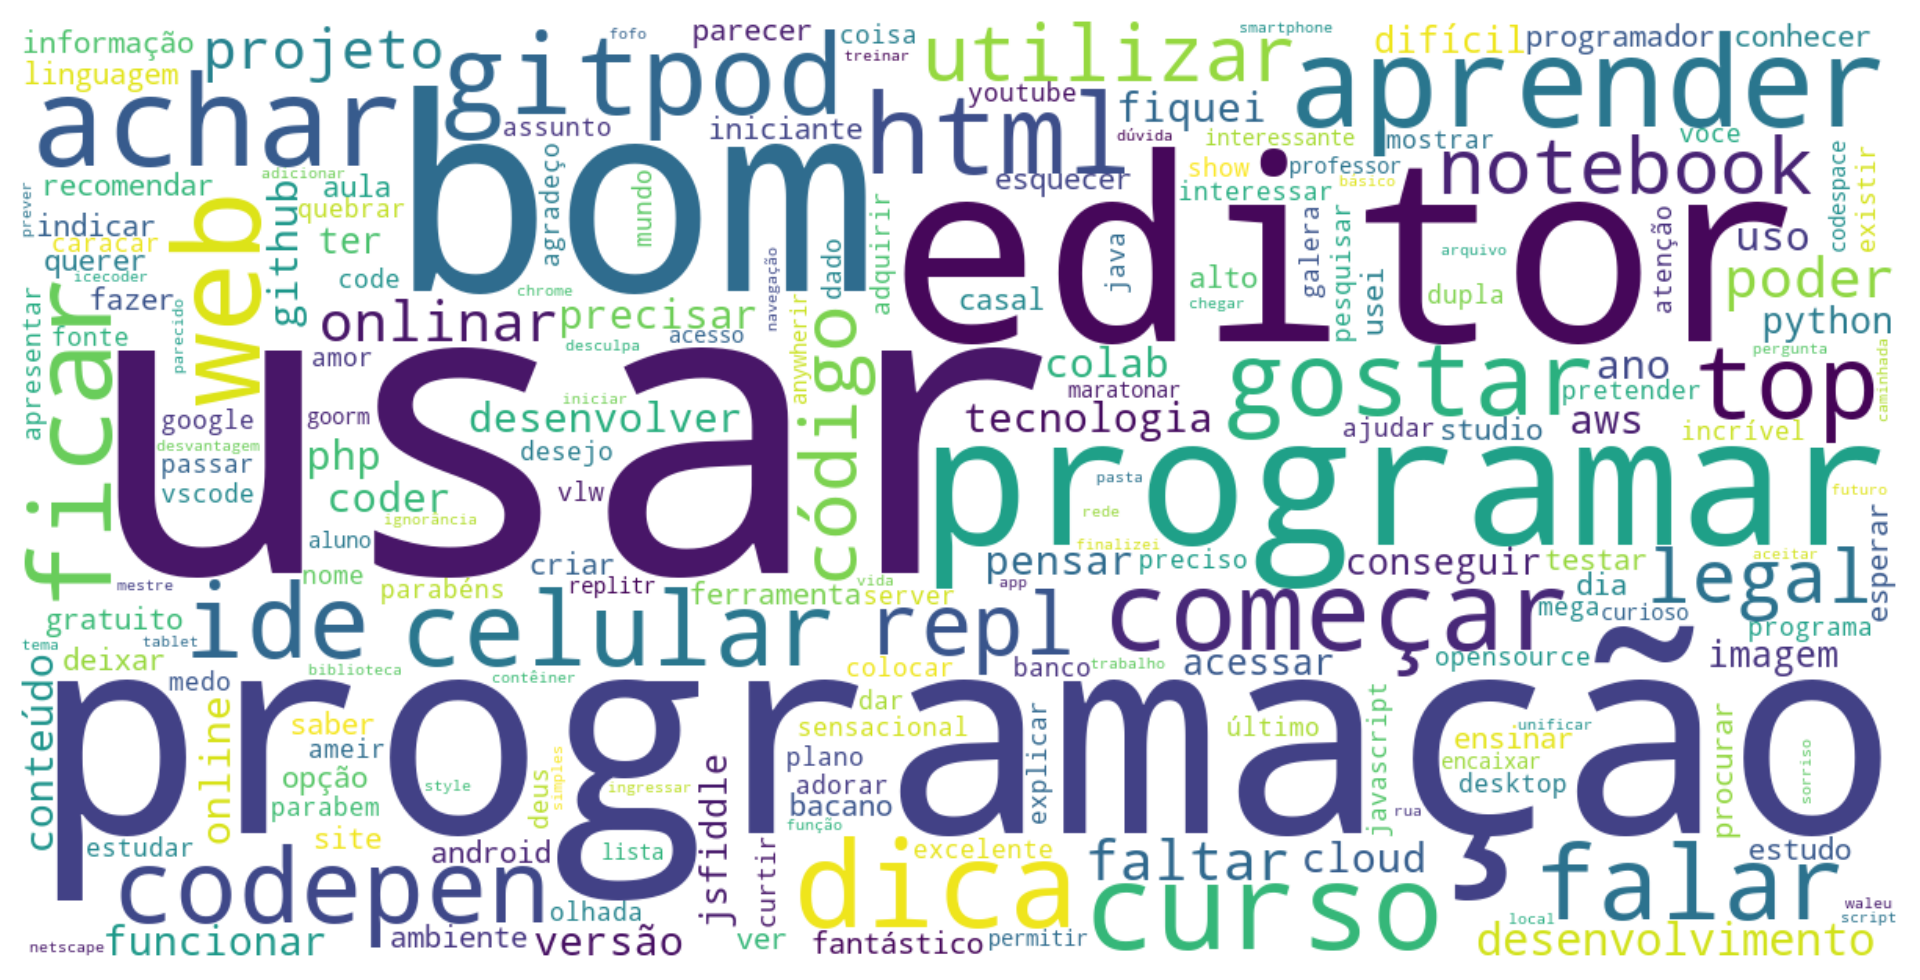

**Qual a Melhor IDE para Python? PyCharm, VSCode, Jupyter, Colab** (`qD3zyh7-hpw`)

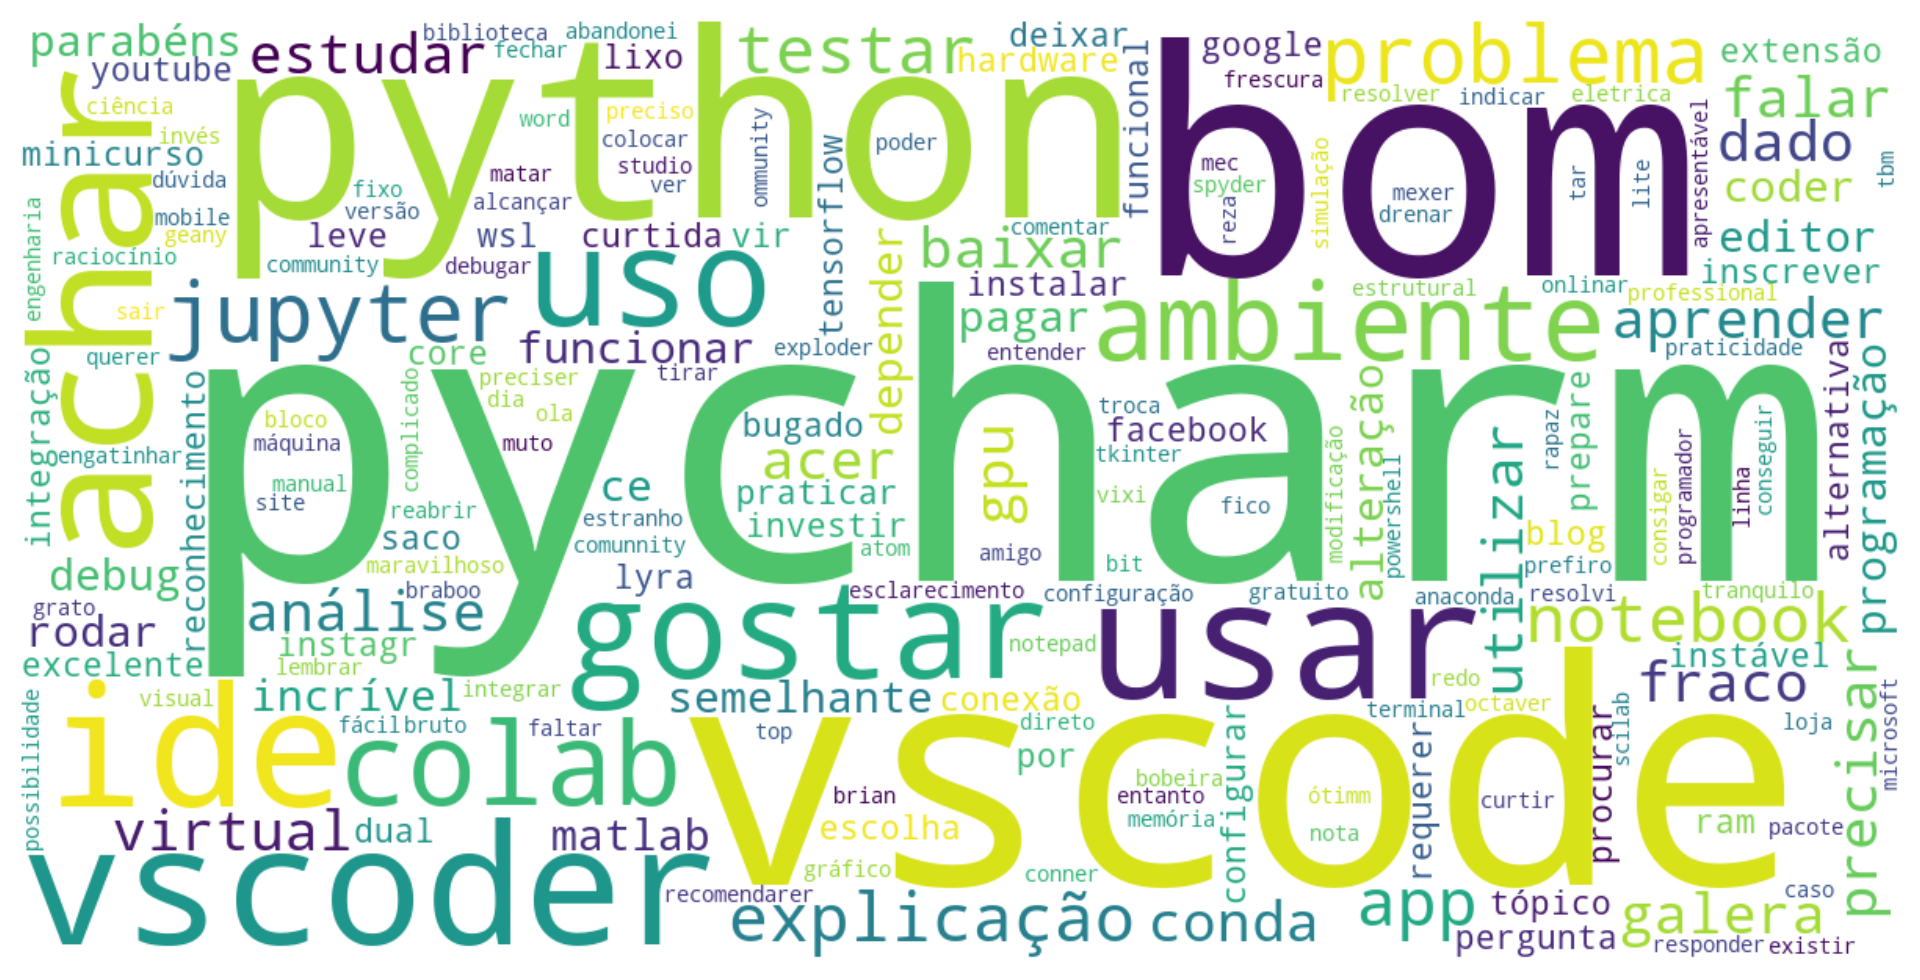

**Quais IDEs os engenheiros de software adoram e por quê?** (`Sd_PpMlPmWY`)

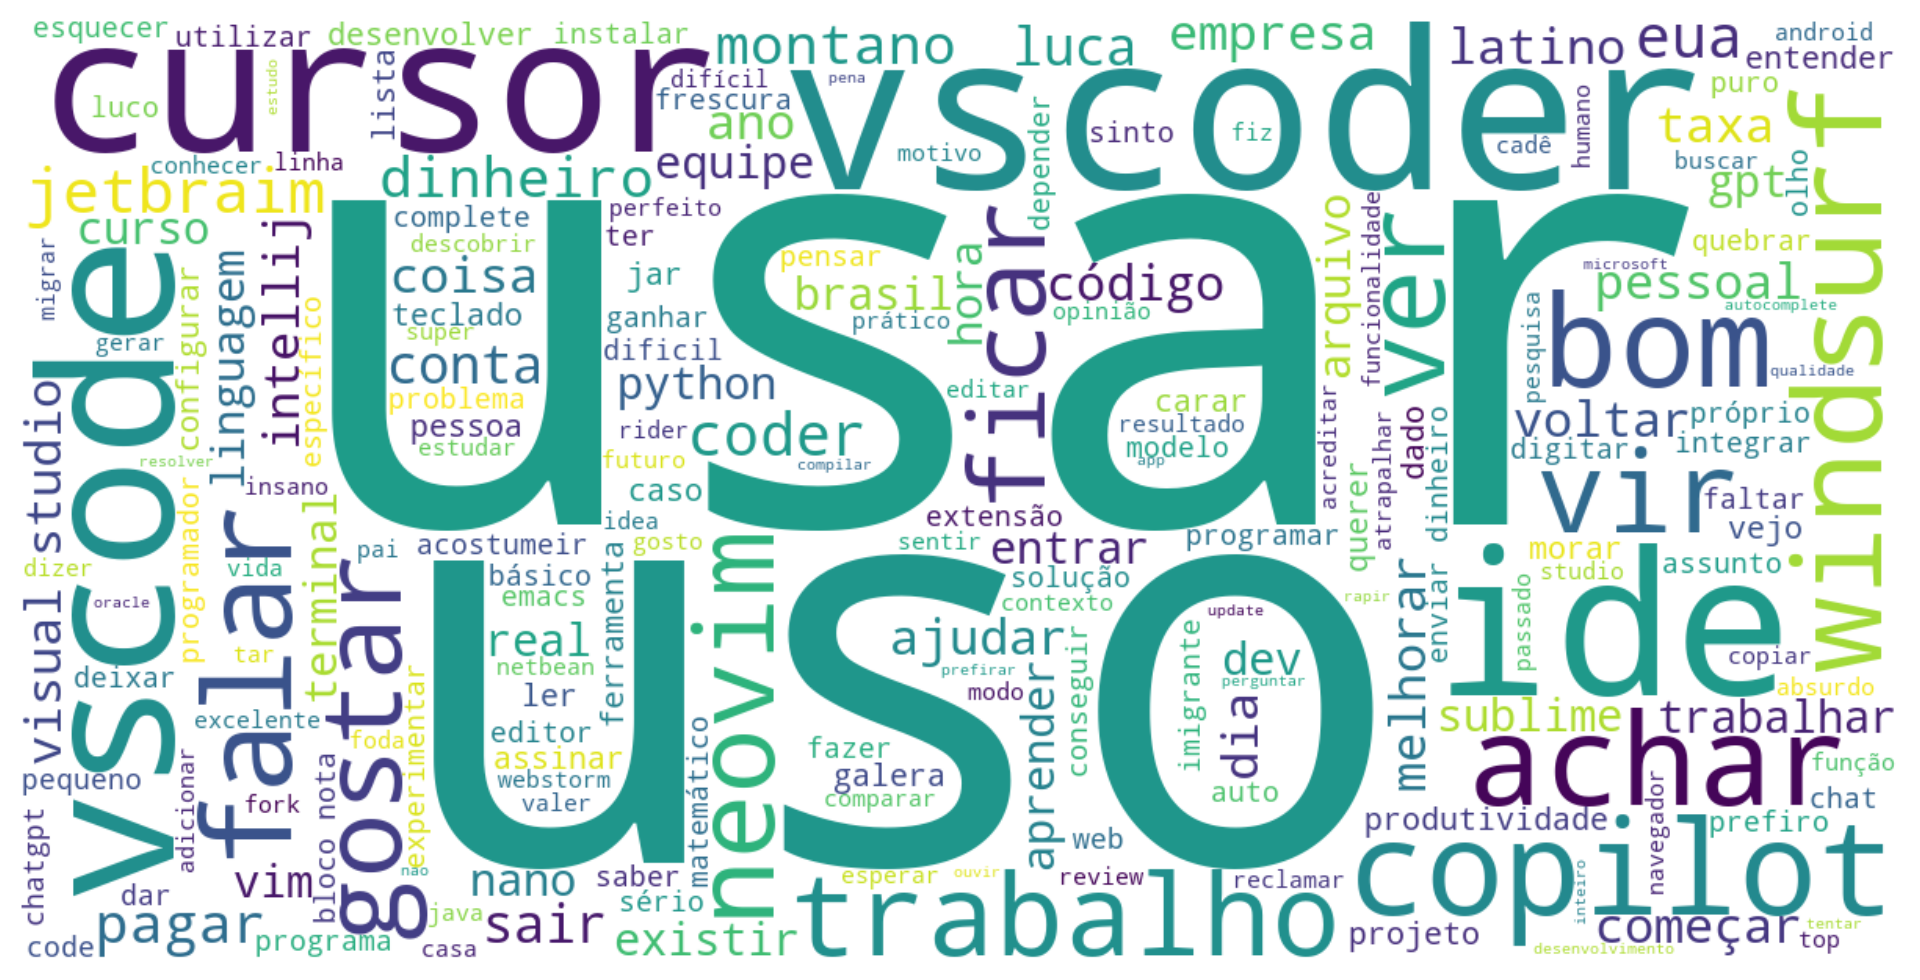

In [7]:
for caminho in sorted(ASSETS.glob("nuvem_*.png")):
    video = caminho.stem.replace("nuvem_", "")
    titulo = df.loc[df.video_id == video, "titulo_video"].iloc[0]
    display(Markdown(f"**{titulo}** (`{video}`)"))
    display(Image(filename=caminho, width=700))

## 7. Entidades e emojis

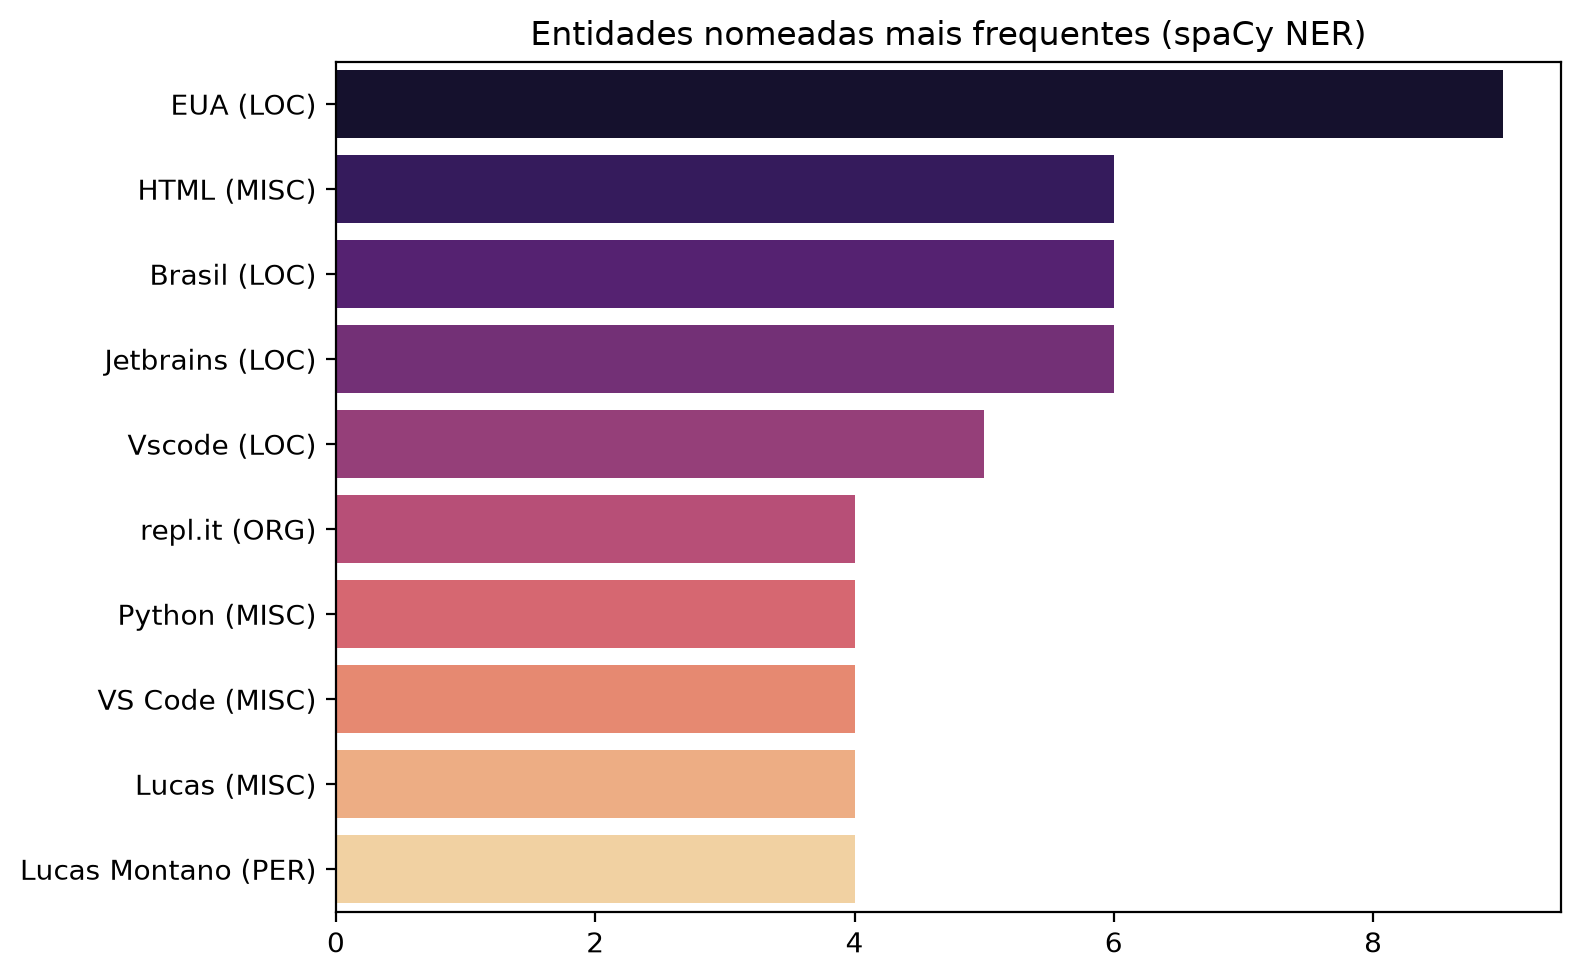

**Emojis mais usados**

,0,1,2,3,4,5,6,7,8,9
emoji,👏,😂,😅,🤔,🤢,😍,🤩,👍,🤷‍♂,💅
frequencia,22,20,4,3,3,2,2,2,2,2


Risadas (kkk/haha/rs): 29 comentários | timestamps citados: 2 comentários


In [8]:
display(Image(filename=ASSETS / "entidades.png", width=600))
emojis = pd.read_csv(TABELAS / "top_emojis.csv")
display(Markdown("**Emojis mais usados**"))
display(emojis.T if not emojis.empty else "Nenhum emoji nos comentários classificados.")
print(f"Risadas (kkk/haha/rs): {int((df['n_risadas'] > 0).sum())} comentários | "
      f"timestamps citados: {int((df['n_timestamps'] > 0).sum())} comentários")

## 8. Exemplos reais
Gráfico convence mais com comentários de exemplo. Abaixo: os mais curtidos de cada sentimento.

In [9]:
def mostrar(sub, titulo):
    display(Markdown(f"### {titulo}"))
    for _, l in sub.iterrows():
        print(f"[{l.video_id} | {l.curtidas} curtidas | score {l.score:+.2f}]")
        print(textwrap.fill(l.texto, 110, initial_indent="  ", subsequent_indent="  "))
        print()

N = 3
for s in ["positivo", "negativo"]:
    mostrar(df[df.sentimento == s].nlargest(N, "curtidas"), f"Comentários {s}s mais curtidos")

### Comentários positivos mais curtidos

[40QyA5f3Qo0 | 70 curtidas | score +0.96]
  Poxa galera esse foi um dos vídeos mais interessantes pra mim, pois é a solução que precisava para ensinar
  meus alunos, que não tem recursos computacionais para rodar um framework. Muito obrigado!!

[Sd_PpMlPmWY | 36 curtidas | score +0.83]
  Eu tenho muitas, mas "intelijeeeeei" e "viéssicode" são minhas favoritas.

[qD3zyh7-hpw | 17 curtidas | score +0.99]
  Videos sempre muito bons, vlw Brian O'conner da programação!



### Comentários negativos mais curtidos

[Sd_PpMlPmWY | 9 curtidas | score -0.86]
  Cadê o Frontpage 98 com copilot?

[Sd_PpMlPmWY | 5 curtidas | score -0.98]
  Decepcionado que o Visualg com Copilot não está na lista...

[Sd_PpMlPmWY | 5 curtidas | score -0.65]
  Não sei pra que inventar moda, vscode já tem quase tudo, só falta uma bind pra subir ou descer pra outra
  função



## 9. Onde o modelo pode ter errado
Comentários em que o modelo ficou **menos confiante** (maior probabilidade ≤ 50%). Ironia e gírias são os casos típicos.

In [10]:
df["confianca"] = df[["p_pos", "p_neu", "p_neg"]].max(axis=1)
duvidosos = df[df.texto_leve.str.split().str.len() >= 5].nsmallest(5, "confianca")
for _, l in duvidosos.iterrows():
    print(f"[{l.sentimento} | confiança {l.confianca:.0%}]")
    print(textwrap.fill(l.texto, 110, initial_indent="  ", subsequent_indent="  "))
    print()

[negativo | confiança 43%]
  Aaa me salvaram, meu computar de 32 bits não dava pra nada, não sabia que existia uma vesão web do Vscode 🤡

[positivo | confiança 44%]
  Minha pasta com blocos de códigos pré formatados é coisa do passado.😂😂😂

[positivo | confiança 46%]
  intellij pra programar em java é simplesmente absurdo

[neutro | confiança 47%]
  Eu tenho usado o Windsurf. O agent realmente é bom, mas já estou olhando pra trás e com vontade de voltar a
  assinar o Cursor.

[positivo | confiança 49%]
  Dae Lucas, difícil eu comentar pq não tenho muitas esperanças de que vc vai ler 😂 mas queria te dizer que
  tenho me obrigado a usar copilot chat no vscode e tenho me impressionado como isso tem aumtendado minha
  produtividade. Sou dev a 15 anos e como eu falei, me obriguei a usar IA no meu workflow. É possível
  adicionar arquivos em um contexto e ter esta funcionalidade de chat. Recomendo que você dê uma chance a usar
  essas funcionalidades  para poder aumentar sua perspectiva sobre

## 10. Limitações
- Poucos comentários por vídeo → intervalos largos; não generalizar para "o público do YouTube".
- A amostra são os comentários mais recentes, com respostas na ordem da API.
- Ironia, sarcasmo e gírias de programação confundem o modelo; o `pt_core_news_sm` erra parte das entidades e lemas.
- Comentários em outros idiomas (texto longo) ficaram fora do recorte.